# 4. Structure factor (spectral correlations) 

In [5]:
import numpy as np
import pandas as pd
import os

from surface_functions import compute_structure_factor

In [6]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"Columnar": {"EW": 3/2, "KPZ": 1.4}} # anomalous scaling, only for columnar noise
alpha_loc_dict = {"Columnar": {"KPZ": 0.97}} # anomalous scaling, only for columnar noise in the KPZ case
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

## Dataframe computations

In [3]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"Output{typenoise}/Solutions_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        structurefactor_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            structurefactor = np.asarray(compute_structure_factor(phases), dtype=float)

            structurefactor_list.append(structurefactor)

        # Avoid chained-assignment issues
        df = df.copy()
        df["structurefactor"] = structurefactor_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE STRUCTURE FACTOR PER (K, L, T) ##
        # group by K, L, T and compute mean structure factor for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            structurefactor_arrays = [np.asarray(r, dtype=float) for r in group["structurefactor"]]
            mean_structurefactor = np.mean(np.stack(structurefactor_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_structurefactor": mean_structurefactor,
                }
            )

        print("Seeds (index):", df.index.tolist())
        # print("Number of simulations:", M)
        print("Columns:", df.columns.tolist())

## TimeDep – Delta 0
Seeds (index): ['L500_K1_seed78375102', 'L500_K1_seed48022158', 'L500_K1_seed21517135', 'L500_K1_seed73450932', 'L500_K1_seed5701930', 'L500_K0.01_seed66323775', 'L500_K1_seed66955334', 'L500_K0.01_seed51276577', 'L500_K1_seed66776927', 'L500_K0.01_seed39155229', 'L500_K1_seed10688739', 'L500_K0.01_seed74911657', 'L500_K1_seed14995512', 'L500_K0.01_seed92687884', 'L500_K1_seed11013623', 'L500_K0.01_seed77570756', 'L500_K1_seed26524819', 'L500_K0.01_seed87634771', 'L500_K1_seed61884301', 'L500_K0.01_seed87439695', 'L500_K1_seed70493549', 'L500_K0.01_seed46007736', 'L500_K1_seed16437593', 'L500_K0.01_seed55248971', 'L500_K1_seed13595782', 'L500_K0.01_seed18901207', 'L500_K1_seed41894445', 'L500_K0.01_seed90297636', 'L500_K1_seed7367704', 'L500_K0.01_seed24097069', 'L500_K1_seed78608552', 'L500_K0.01_seed73001616', 'L500_K1_seed46449722', 'L500_K0.01_seed31008285', 'L500_K1_seed22480058', 'L500_K1_seed4733608', 'L500_K0.01_seed39831824', 'L500_K1_seed92871047', 'L500_

In [4]:
# === add this after the loops ===
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_structurefactor"] = new_avg["mean_structurefactor"]

avg_df.to_pickle(avg_df_path)

In [5]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2,mean_heightheight,mean_structurefactor
avg_id,,,,,,,,,,,,
TimeDep_delta0_L500_K0.01_T20000_M500,TimeDep,0.000000,0,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.09932794776024303, 0.12445710235930987...","[0.0, 0.09937158963203278, 0.12451669747551469...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L125_K1.0_T20000_M1000,TimeDep,0.000000,0,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.06206535180620217, 0.06962088956407118...","[0.0, 0.06224447417192954, 0.06987538331690908...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L250_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.06185445817599045, 0.0696865309816036,...","[0.0, 0.061951592706644056, 0.0698286189854493...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_delta0_L500_K1.0_T20000_M500,TimeDep,0.000000,0,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.062281209851627814, 0.0703404523305143...","[0.0, 0.062330873676472595, 0.0704074790636151...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K0.01_T20000_M500,TimeDep,1.373401,atan5,0.01,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.10014740577543957, 0.1261770083222738,...","[0.0, 0.10019634453950993, 0.12623155432190383...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L125_K1.0_T20000_M1000,TimeDep,1.373401,atan5,1.00,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1000,20000,"[0.0, 0.08497581574082771, 0.10016716020392952...","[0.0, 0.085169740061077, 0.10039858844247401, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L250_K1.0_T20000_M500,TimeDep,1.373401,atan5,1.00,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.08525314007445625, 0.10040309251048023...","[0.0, 0.08534060165610576, 0.10051558946041181...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
TimeDep_deltaatan5_L500_K1.0_T20000_M500,TimeDep,1.373401,atan5,1.00,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.08538735713321526, 0.10092130285727816...","[0.0, 0.08543379532608593, 0.10098882300685771...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."
Columnar_delta0_L500_K0.02_T20000_M500,Columnar,0.000000,0,0.02,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",500,20000,"[0.0, 0.5718230273546884, 0.9065624021882813, ...","[0.0, 0.5719428387249444, 0.9067554902468036, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,..."


## Inspection of the computed quantities

In [7]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

In [52]:
avg_df_path = "AverageSims.pkl"
avg_df = pd.read_pickle(avg_df_path)

L = 500
T = 20000

In [53]:
markerdict = {500: "o", 250: "x", 125: "^", 1000: "s"}

/tmp/ipykernel_32481/2488922418.py:53: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1,0].set_ylim(0,1e3)


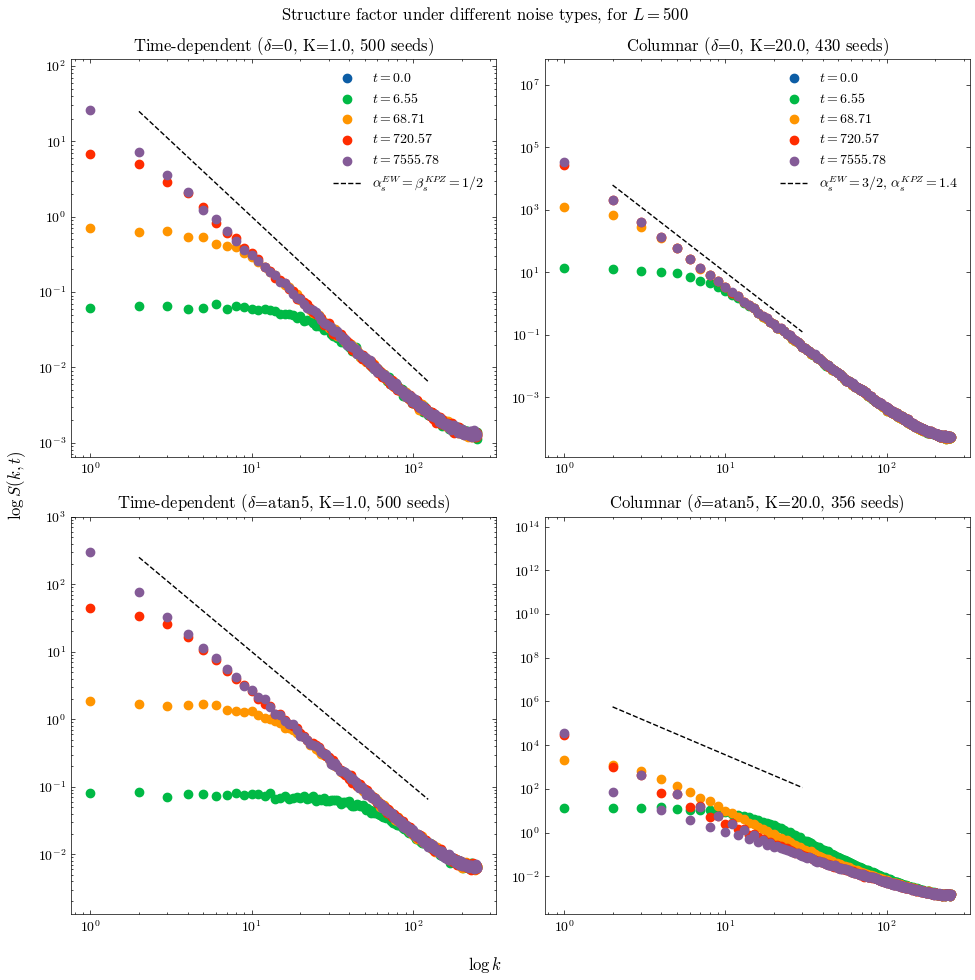

In [54]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("Structure factor under different noise types, for $L=$" + str(L))

fig.supxlabel(r"$\log k$")
fig.supylabel(r"$\log S(k,t)$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
):

    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 1) | (avg_df["K"] == 20))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]            
            mean_structurefactor = row["mean_structurefactor"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            for ti in range(mean_structurefactor.shape[0])[::5]:
                klen = mean_structurefactor.shape[1] # we only plot up to half due to nyquist
                krange = np.array(range(klen))
                ax[j,i].scatter(krange[:int(klen/2)], mean_structurefactor[ti,:int(klen/2)], label=f"$t=${np.round(t[ti],2)}", marker=markerdict[L])
            ax[j,i].set_title(typelabel+ r" ($\delta$="+f"{deltaname}, K={K}, {M} seeds)")

ax[0,0].set_yscale('log')
ax[0,0].set_xscale('log')
ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')
ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')
ax[1,1].set_yscale('log')
ax[1,1].set_xscale('log')

# scaling as k^(-2*alpha-1) = k^2 for alpha = 1/2 (EW/KPZ)
ax[0,0].loglog(krange[2:int(klen/4)], krange[2:int(klen/4)]**(-2*alpha_dict["TimeDep"]["EW"]-1) * 100, label=r"$\alpha_s^{EW}=\beta_s^{KPZ}=1/2$", linestyle="--", color="k")
ax[1,0].loglog(krange[2:int(klen/4)], krange[2:int(klen/4)]**(-2*alpha_dict["TimeDep"]["KPZ"]-1) * 1000, linestyle="--", color="k")

# # scaling as k^(-2*alpha_s-1) for alpha_s approx 3/2 (EW) or 1.4 (KPZ)
ax[0,1].loglog(krange[2:int(klen/16)], krange[2:int(klen/16)]**(-2*alpha_dict["Columnar"]["EW"]-1) * 100000, label=r"$\alpha_s^{EW}=3/2,\,\alpha_s^{KPZ}=1.4$", linestyle="--", color="k")
ax[1,1].loglog(krange[2:int(klen/16)], krange[2:int(klen/16)]**(-2*alpha_dict["Columnar"]["KPZ"]-1) * 5000000, linestyle="--", color="k")

ax[1,0].set_ylim(0,1e3)

ax[0,0].legend()
ax[0,1].legend()

plt.tight_layout()
plt.show()

In [55]:
alpha_dict, alpha_s_dict, alpha_loc_dict

({'TimeDep': {'EW': 0.5, 'KPZ': 0.5}, 'Columnar': {'EW': 1.5, 'KPZ': 1.07}},
 {'Columnar': {'EW': 1.5, 'KPZ': 1.4}},
 {'Columnar': {'KPZ': 0.97}})

#### Family-Vicsek collapse of the structure factor

18 2951.4714757357383
20 7555.783777891889
22 19342.819671409838
14 450.3502251751126
16 1152.9205764602884
18 2951.4714757357383
18 2951.4714757357383
20 7555.783777891889
22 19342.819671409838
14 450.3502251751126
16 1152.9205764602884
18 2951.4714757357383


/tmp/ipykernel_32481/3568642693.py:60: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1,0].set_ylim(0,1e3)


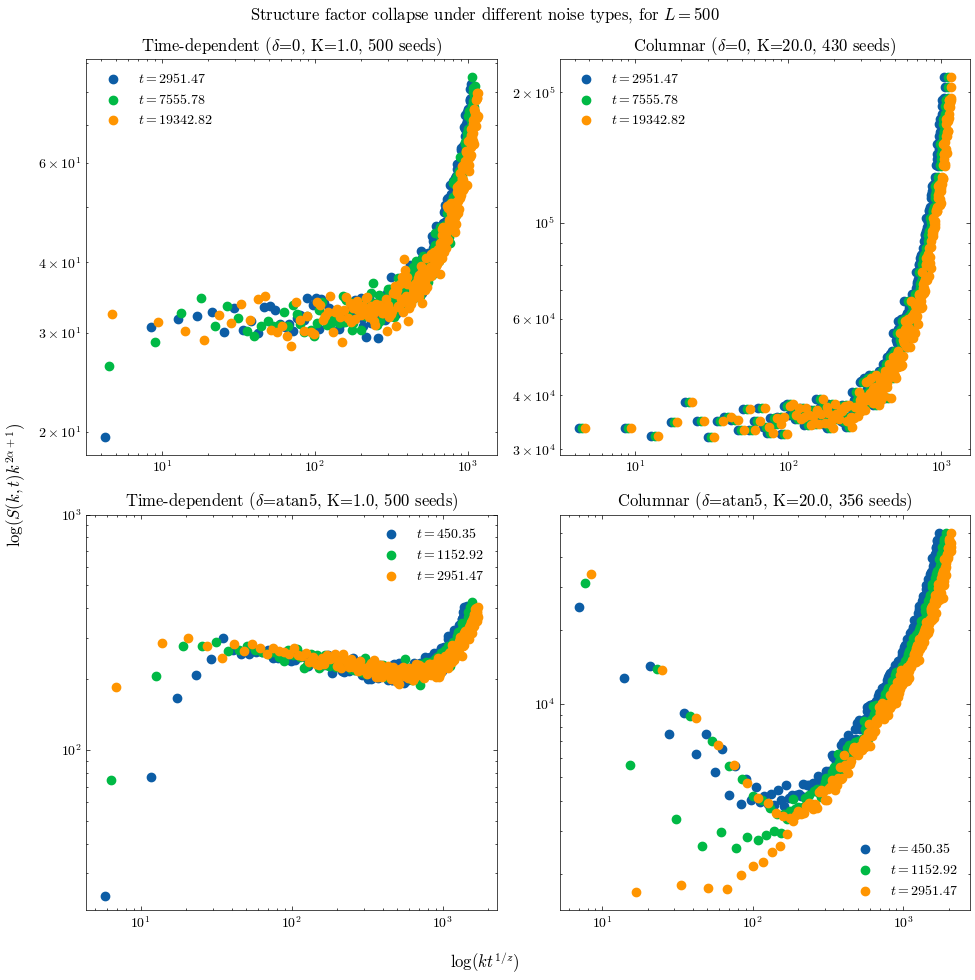

In [56]:
fig, ax = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle("Structure factor collapse under different noise types, for $L=$" + str(L))

fig.supxlabel(r"$\log (k t^{1/z})$")
fig.supylabel(r"$\log (S(k,t) k^{2\alpha+1})$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent", "Columnar"])
):

    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(5)], ["0", "atan5"])):

        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["L"] == L)
            & (avg_df["T"] == T)
            & (avg_df["deltaname"] == deltaname)
            & ((avg_df["K"] == 1) | (avg_df["K"] == 20))
        )
        sub = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub.iterrows():
            t = row["t"]            
            mean_structurefactor = row["mean_structurefactor"]
            L = row["L"]
            K = row["K"]
            M = row["M"]

            tilist = [18,20,22] if deltaname == "0" else [14,16,18]
            
            for ti in tilist:
                print(ti, t[ti])
                klen = mean_structurefactor.shape[1] # we only plot up to half due to nyquist
                krange = np.array(range(klen))
                kt1z = krange[:int(klen/2)] * ti**(1/z_dict[typenoise][delta_to_label[deltaname]])
                Sk2a = mean_structurefactor[ti,:int(klen/2)] * krange[:int(klen/2)]**(2*alpha_dict[typenoise][delta_to_label[deltaname]]+1)
                ax[j,i].scatter(kt1z, Sk2a,
                                label=f"$t=${np.round(t[ti],2)}", 
                                marker=markerdict[L])
            ax[j,i].set_title(typelabel+ r" ($\delta$="+f"{deltaname}, K={K}, {M} seeds)")

ax[0,0].set_yscale('log')
ax[0,0].set_xscale('log')
ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')
ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')
ax[1,1].set_yscale('log')
ax[1,1].set_xscale('log')

# scaling as y^(2*alpha+1) = k^2 for alpha = 1/2 (EW/KPZ)
# ax[0,0].loglog(krange[3:int(klen/32)], krange[3:int(klen/32)]**(2*alpha_dict["TimeDep"]["EW"]+1) / 10, label=r"$\alpha_s^{EW}=\alpha_s^{KPZ}=1/2$", linestyle="--", color="k")
# ax[1,0].loglog(krange[4:int(klen/16)], krange[4:int(klen/16)]**(2*alpha_dict["TimeDep"]["KPZ"]+1) / 10, linestyle="--", color="k")

# scaling as k^(-2*alpha_s-1) for alpha_s approx 3/2 (EW) or 1.4 (KPZ)
# ax[0,1].loglog(krange[2:int(klen/16)], krange[2:int(klen/16)]**(-2*alpha_dict["Columnar"]["EW"]-1) * 100000, label=r"$\alpha_s^{EW}=3/2,\,\alpha_s^{KPZ}=1.4$", linestyle="--", color="k")
# ax[1,1].loglog(krange[2:int(klen/16)], krange[2:int(klen/16)]**(-2*alpha_dict["Columnar"]["KPZ"]-1) * 5000000, linestyle="--", color="k")

ax[1,0].set_ylim(0,1e3)

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
plt.show()

In [57]:
t

array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
       4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
       2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
       1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
       1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
       7.55578378e+03, 1.20892560e+04, 1.93428197e+04])

In [58]:
(L/8)**2, (L/4)**2, (L/2)**2

(3906.25, 15625.0, 62500.0)

In [59]:
print(t[[18,20,22]])

[ 2951.47147574  7555.78377789 19342.81967141]


In [60]:
(L/8)**(3/2), (L/4)**(3/2), (L/2)**(3/2)

(494.10588440130925, 1397.5424859373686, 3952.847075210474)

In [61]:
print(t[[14,16,18]])

[ 450.35022518 1152.92057646 2951.47147574]
